In [1]:
%load_ext autoreload
%autoreload 2

In [145]:
import sys
sys.path.append("/home/pwiesenbach/BertGCN")

from utils import *
import json 
import pandas as pd
import random
from pathlib import Path
import pickle
from transformers import AutoTokenizer
from torch.utils.data import Subset
import re

In [4]:
MODELTYPE = "deepset/gbert-base"
DATASET = "med_indication_all_RF_diag"
DATASETPATH =  Path("/home/pwiesenbach/BertGCN/data") / f"ind.{DATASET}"
DATASETFILE = Path("/home/pwiesenbach/BertGCN/data") / "medindcls_bert.json"

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASETPATH)
doc_mask = train_mask + val_mask + test_mask
adj.sum()

tokenizer = AutoTokenizer.from_pretrained(MODELTYPE)

if not DATASETFILE.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(DATASETFILE, "wb") as f:
        print(f"Saving dataset under {DATASETFILE}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {DATASETFILE}")
    with open(DATASETFILE, "rb") as f:
        dataset = pickle.load(f)

Loading dataset from: /home/pwiesenbach/BertGCN/data/medindcls_bert.json


/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator LabelEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/pwiesenbach/anaconda3/envs/pytorch/lib/python3.10/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator OneHotEncoder from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/tmp/ipykernel_221906/1302114904.py:21: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  dataset = pickle.loa

In [6]:
mixfactor = 0.5
ig_gcn_bert_path = f"/home/pwiesenbach/BertGCN/models/gcn/{mixfactor}/ig_attrs_gcn_bert.json"
shap_gcn_bert_path = f"/home/pwiesenbach/BertGCN/models/gcn/{mixfactor}/shap_values_gcn_bert.json"

ig_gcn_bert_values = pickle.load(open(ig_gcn_bert_path, "rb"))
shap_gcn_bert_values = pickle.load(open(shap_gcn_bert_path, "rb"))

In [28]:
top_n_interpret = 3
top_ig_gcn_bert_values = np.argpartition(ig_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]
top_shap_gcn_bert_values = np.argpartition(shap_gcn_bert_values, -top_n_interpret)[:, -top_n_interpret:]

In [41]:
random.seed(0)
idx = np.arange(len(dataset))
random.shuffle(idx)

train_len = 1889
val_len = 270
test_len = 540
nb_word = 25297

train_idx, val_idx, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)
    
def map_to_idx(x):
    if x < train_len:
        return train_idx[x]
    elif x < val_len + train_len:
        return val_idx[x - train_len]
    else:
        return x - val_len - train_len

In [30]:
top_ig_gcn_bert_values = np.vectorize(map_to_idx)(top_ig_gcn_bert_values)
top_shap_gcn_bert_values = np.vectorize(map_to_idx)(top_shap_gcn_bert_values)

In [22]:
first_order_adj = adj @ adj
first_order_adj = first_order_adj.toarray()

In [31]:
top_n_input = 10
top_input_test_rel_nodes = np.argpartition(first_order_adj[test_mask][:, doc_mask], -top_n_input)[:, -top_n_input:]
top_input_test_rel_nodes = np.vectorize(map_to_idx)(top_input_test_rel_nodes)
top_input_test_rel_nodes.max(), top_input_test_rel_nodes.shape

(2687, (540, 10))

In [32]:
s = 0
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

s = 0
for a, b in zip(top_input_test_rel_nodes, top_shap_gcn_bert_values):
    s += len(np.intersect1d(a, b))
print(s)

1305
1307


In [60]:
input_only, interpret_only, both = list(), list(), list()
for a, b in zip(top_input_test_rel_nodes, top_ig_gcn_bert_values):
    input_only.append(np.setdiff1d(a, b))
    interpret_only.append(np.setdiff1d(b, a))
    both.append(np.intersect1d(b, a))
compare_df = pd.DataFrame({"interpret only": interpret_only, "input only": input_only, "both": both}, index=test_idx)
compare_df

,interpret only,input only,both
2298,[],"[0, 193, 291, 335, 2293, 2294, 2295]","[512, 2291, 2300]"
2130,[],"[1, 22, 23, 24, 125, 501, 2132]","[252, 2131, 2136]"
2559,[],"[118, 188, 494, 2556, 2560, 2562, 2564]","[2, 2557, 2563]"
1046,"[1594, 1595, 1599]","[3, 110, 254, 1044, 1045, 1047, 1048, 1049, 10...",[]
1991,"[443, 1355]","[35, 73, 75, 79, 80, 84, 247, 422, 534]",[4]
...,...,...,...
2094,"[287, 1337]","[439, 550, 551, 1600, 1601, 1603, 2092, 2093, ...",[535]
1060,[],"[285, 296, 1055, 1056, 1057, 1058, 1911]","[536, 1054, 1059]"
165,[],"[5, 162, 164, 366, 1133, 1136, 1139]","[245, 248, 537]"
1722,[],"[126, 538, 1721, 1723, 1729, 1730, 1731]","[1726, 1735, 1736]"


In [101]:
compare_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in compare_df.index]

<Axes: >

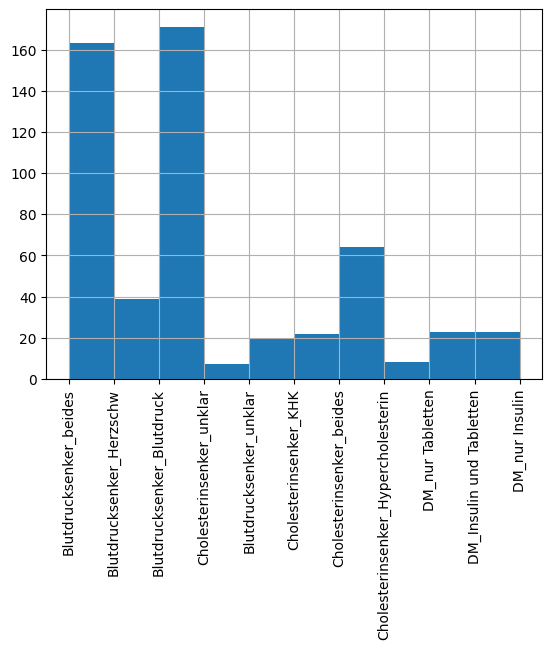

In [107]:
compare_df["data label"].hist(xrot=90)

In [168]:
diff_df = compare_df[compare_df['interpret only'].map(len) == 3]
diff_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in diff_df.index]
diff_df["arznei"] = [re.findall("Arznei (\w+) &", dataset.texts[x])[0] for x in diff_df.index]
diff_df["interpret labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in diff_df["interpret only"]]
diff_df["interpret arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in diff_df["interpret only"]]
diff_df["input labels"] = [dataset.LE.classes_[[dataset[y]["labels"] for y in x]] for x in diff_df["input only"]]
diff_df["input arznei"] = [[re.findall("Arznei (.+?) &", dataset.texts[y])[0] for y in x] for x in diff_df["input only"]]
diff_df["label overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(diff_df["interpret labels"], diff_df["input labels"])]
diff_df["arznei overlap"] = [sum([xx in y for xx in x])/3 for x, y in zip(diff_df["interpret arznei"], diff_df["input arznei"])]
diff_df["interpret label equals data label"] = [sum([xx==y for xx in x])/3 for x, y in zip(diff_df["interpret labels"], diff_df["data label"])]
diff_df["interpret arznei equals data label"] = [sum([xx==y for xx in x])/3 for x, y in zip(diff_df["interpret arznei"], diff_df["arznei"])]
diff_df.head()

/tmp/ipykernel_221906/2802231945.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_df["data label"] = [dataset.LE.classes_[dataset[x]["labels"]] for x in diff_df.index]
/tmp/ipykernel_221906/2802231945.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_df["arznei"] = [re.findall("Arznei (\w+) &", dataset.texts[x])[0] for x in diff_df.index]
/tmp/ipykernel_221906/2802231945.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

,interpret only,input only,both,data label,arznei,interpret labels,interpret arznei,input labels,input arznei,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data label
1046,"[1594, 1595, 1599]","[3, 110, 254, 1044, 1045, 1047, 1048, 1049, 10...",[],Cholesterinsenker_unklar,Atorvastatin,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Beloc, Valsartan, Eplerenon]","[Blutdrucksenker_beides, DM_nur Tabletten, DM_...","[Candesartan, Glimepirid, Metformin, Bisoprolo...",0.000000,0.000000,0.000000,0.000000
2537,"[81, 1740, 1784]","[38, 124, 329, 369, 2534, 2535, 2536, 2538, 25...",[],Cholesterinsenker_Hypercholesterin,Pravastatin,"[Cholesterinsenker_KHK, Blutdrucksenker_beides...","[SortisUNK, Metoprololsucc, Pravastatin]","[Blutdrucksenker_unklar, DM_Insulin und Tablet...","[Ramipril, Novorapid, Valsartan, Verapamil, Ne...",0.333333,0.333333,0.000000,0.333333
1368,"[1235, 1628, 1629]","[54, 181, 224, 312, 490, 1366, 1367, 1370, 137...",[],Cholesterinsenker_beides,Atorvastatin,"[Blutdrucksenker_unklar, Cholesterinsenker_unk...","[Rampril, Pravasin, Pravastatin]","[DM_nur Tabletten, Blutdrucksenker_Blutdruck, ...","[Metformin, Spironolacton, Bisoprololfumarat, ...",0.000000,0.000000,0.000000,0.000000
1073,"[155, 277, 278]","[64, 1074, 1512, 1513, 1514, 1515, 2120, 2122,...",[],Blutdrucksenker_unklar,Metoprolol,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Ramipril, Diovan, Valsartan]","[Cholesterinsenker_beides, Cholesterinsenker_K...","[Sortis, Simvastatin, Metoprolol, Delix, Inspr...",0.000000,0.333333,1.000000,0.000000
2170,"[87, 1923, 2162]","[270, 293, 351, 2159, 2161, 2163, 2165, 2169, ...",[],Cholesterinsenker_KHK,Atorvastatin,"[Blutdrucksenker_unklar, Blutdrucksenker_Blutd...","[Delix, HCT, Atorvastatin]","[DM_nur Tabletten, Blutdrucksenker_Blutdruck, ...","[Metformin, Ramipril, Spironolacton, Belok, Ep...",0.333333,0.000000,0.333333,0.333333


In [169]:
diff_df.describe()

,label overlap,arznei overlap,interpret label equals data label,interpret arznei equals data label
count,32.000000,32.000000,32.000000,32.000000
mean,0.312500,0.145833,0.145833,0.083333
std,0.358586,0.238536,0.223005,0.146647
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.333333,0.000000,0.000000,0.000000
75%,0.333333,0.333333,0.333333,0.083333
max,1.000000,0.666667,1.000000,0.333333


In [161]:
re.findall("Arznei (\w+) &", dataset.texts[38])[0]

'Ramipril'

<Axes: >

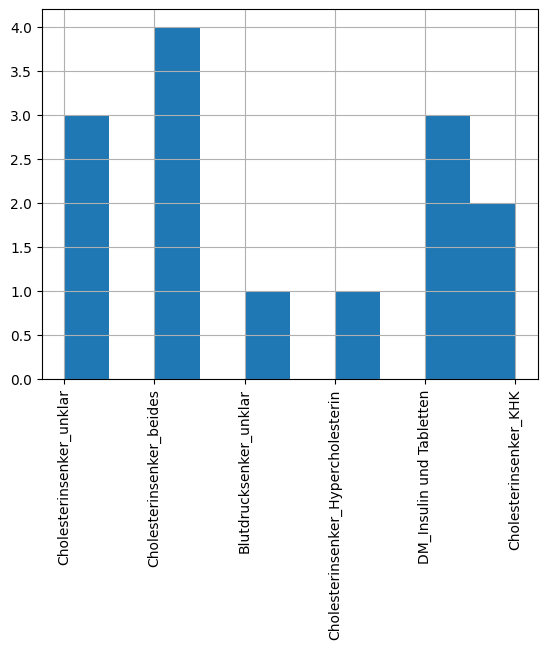

In [129]:
diff_df[(diff_df["label overlap"]==0)]["data label"].hist(xrot=90)

In [121]:
diff_df[diff_df["interpret label equals data label"] == 1.]

,interpret only,input only,both,data label,interpret labels,input labels,label overlap,interpret label equals data label
1073,"[155, 277, 278]","[64, 1074, 1512, 1513, 1514, 1515, 2120, 2122,...",[],Blutdrucksenker_unklar,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Cholesterinsenker_beides, Cholesterinsenker_K...",0.0,1.0


In [127]:
diff_df[(diff_df["label overlap"]==0) & (diff_df["interpret label equals data label"]==1.)]

,interpret only,input only,both,data label,interpret labels,input labels,label overlap,interpret label equals data label
1073,"[155, 277, 278]","[64, 1074, 1512, 1513, 1514, 1515, 2120, 2122,...",[],Blutdrucksenker_unklar,"[Blutdrucksenker_unklar, Blutdrucksenker_unkla...","[Cholesterinsenker_beides, Cholesterinsenker_K...",0.0,1.0


<Axes: >

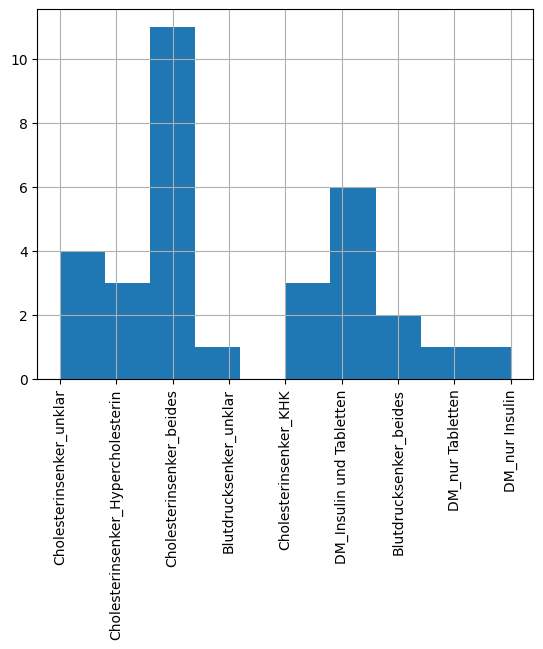

In [109]:
diff_df["data label"].hist(xrot=90)

In [130]:
" ".join(dataset.texts[diff_df.index[0]].split()[:512])

'Arznei Atorvastatin & Aufnahmedatum : < [ Pseudo ] 2029 - 02 - 24 > Geburtsdatum : < [ Pseudo ] 1970 - 09 - 16 > Alter : 58 über Ihre Patientin B-SALUTE B-PER I-PER geboren am B-DATE wohnhaft in B-PLZ B-LOC I-ADDR I-ADDR die sich vom bis in unserer stationären Behandlung befand . Aktuell : - Atypische Tako-Tsubo-Kardiomyopathie - LRB - Kardio-MRT v . < [ Pseudo ] 21 / 02 / 2029 > - RRB - UNK Leicht - bis mittelgradig eingeschränkte linksventrikuläre Pumpfunktion mit A - bis Dyskinesie apikal auf inferior übergreifend - LRB - Kardio-MRT v . < [ Pseudo ] 21 / 02 / 2029 > - RRB - - Im Wesentlichen unauffällige Koronargefäße - LRB - HK-Nr . : 1032 - DATE v . < [ Pseudo ] 16 / 02 / 2029 > - RRB - UNK Ausschluss Lungenarterienembolie mittels Pulmonalisangiographie UNK Erhöhter enddiastolischer Druck im linken Ventrikel - LRB - ca . 28 mmHg - RRB - UNK Erhöhter pulmonalarterieller Druck - LRB - PAP 45 / 20 / 32 mmHg - RRB - - Mittelgradige Trikuspidalklappeninsuffizienz - LRB - TTE v . < [ P

In [147]:
re.findall("Arznei (\w+) &", dataset.texts[diff_df.index[0]])[0]

'Atorvastatin'

In [141]:
for x in diff_df.iloc[0]["interpret only"]:
    print(" ".join(dataset.texts[x].split()[:512]), end="\n" + "="*150 + "\n")

Arznei Beloc & Aufnahmedatum : < [ Pseudo ] 2030 - 01 - 14 > Geburtsdatum : < [ Pseudo ] 1956 - 05 - 06 > Alter : 73 über Ihren Patienten B-SALUTE B-PER I-PER geboren am B-DATE wh . B-PLZ B-LOC I-ADDR I-ADDR I-ADDR der sich vom bis in unserer stationären Behandlung befand . Diagnosen : - Akuter Myokardinfarkt - LRB - STEMI - RRB - am < [ Pseudo ] 13 / 01 / 2030 > - Koronare 2 - Gefäßerkrankung der LAD und LCX UNK Erfolgreiche Rekanalisation der LAD mittels PTCA / 1 - fach DE-Stentimplantation - LRB - HK-Nr . 3142 - DATE vom < [ Pseudo ] 13 / 01 / 2030 > - RRB - - Z.n . Ablation des langsamen Leitungsweges bei AV-Knoten Reentrytachykardie - LRB - B-DATE B-ORG I-ORG - RRB - - Z.n . Leistenhernienoperation vor Jahren - LRB - anamnestisch - RRB - Kardiovaskuläre Risikofaktoren : Diabetes mellitus II , nicht insulinpflichtig Allergien / Unverträglichkeiten : keine bekannt Anamnese : Die stationäre Aufnahme von B-SALUTE B-PER erfolgte über den Notarzt bei seit dem Vormittag bestehenden stark

In [142]:
for x in diff_df.iloc[0]["input only"]:
    print(" ".join(dataset.texts[x].split()[:512]), end="\n" + "="*150 + "\n")

Arznei Candesartan & Aufnahmedatum : < [ Pseudo ] 2020 - 12 - 19 > Geburtsdatum : < [ Pseudo ] 1952 - 09 - 21 > Alter : 68 über Ihren Patienten B-SALUTE B-PER I-PER geboren am B-DATE wohnhaft in B-PLZ B-LOC I-ADDR I-ADDR der sich vom bis in unserer stationären Behandlung befand . Diagnosen : - Erfolgreiche PTCA und Bare-Metal-Stent-Implantation der RCA am < [ Pseudo ] 12 / 12 / 2020 > - LRB - HK-Nr . 5715 - DATE - RRB - - Koronare 2 - Gefäß-Erkrankung mit leichtgradig eingeschränkter LV-Funktion - Keine signifikanten Pausen in der Langzeit-EKG-Untersuchung - Keine Auslösbarkeit einer vasovagalen Reaktion durch Orthostasebelastung - Persistierendes Vorhofflimmern - Arterielle Hypertonie - Aorteninsuffizienz I ° - Mitralklappeninsuffizienz I ° - Trikuspidalklappeninsuffizienz I ° - Latente Hyperthyreose Anamnese : Die Aufnahme von B-SALUTE B-PER erfolgte notfallmäßig über unsere B-ORG I-ORG I-ORG bei Synkope . Der Patient berichtet über einen am Aufnahmetag plötzlich aufgetretenen Schwin